# 01 Main: Decision-Calibrated Pacing

Compares point-forecast pacing, generic-residual conformal robust pacing, and decision-calibrated robust pacing on the two public-data-calibrated streaming cases.

[forecast] fitting 7 forecasters: blocks=120, dim=48, train_blocks=60
[forecast] point_naive start
[forecast] point_naive done in 0.0s, train_mse=611405, band_radius=4682.58
[forecast] seasonal_ridge start
[forecast] seasonal_ridge done in 0.0s, train_mse=362770, band_radius=3443.88
[forecast] random_feature start
[forecast] random_feature done in 0.0s, train_mse=51775.5, band_radius=1362.16
[forecast] gradient_boosted start
[forecast] gradient_boosted training start: targets=48, train_blocks=60
[forecast] gradient_boosted fitted target 1/48
[forecast] gradient_boosted fitted target 8/48
[forecast] gradient_boosted fitted target 16/48
[forecast] gradient_boosted fitted target 24/48
[forecast] gradient_boosted fitted target 32/48
[forecast] gradient_boosted fitted target 40/48
[forecast] gradient_boosted fitted target 48/48
[forecast] gradient_boosted done in 4.0s, train_mse=276487, band_radius=3027.94
[forecast] numpy_mlp start
[forecast] numpy_mlp training start: epochs=600, hidden=48

/home/apex/Documents/ranking_sys/notebooks/writing/forecast_calibrated_causal_pacing_yield_optimization_streaming_ads/code/src/forecasting.py:375: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers)


[forecast] torch_transformer epoch 70/350, loss=0.00613195
[forecast] torch_transformer epoch 140/350, loss=0.00230195
[forecast] torch_transformer epoch 210/350, loss=0.00178256
[forecast] torch_transformer epoch 280/350, loss=0.00090178
[forecast] torch_transformer epoch 350/350, loss=0.000803212
[forecast] torch_transformer inference start: blocks=108
[forecast] torch_transformer done in 1.4s, train_mse=220.718, band_radius=92.8421
[forecast] fitting 7 forecasters: blocks=120, dim=48, train_blocks=60
[forecast] point_naive start
[forecast] point_naive done in 0.0s, train_mse=135745, band_radius=1212.22
[forecast] seasonal_ridge start
[forecast] seasonal_ridge done in 0.0s, train_mse=90852.4, band_radius=966.933
[forecast] random_feature start
[forecast] random_feature done in 0.0s, train_mse=5905.29, band_radius=309.281
[forecast] gradient_boosted start
[forecast] gradient_boosted training start: targets=48, train_blocks=60
[forecast] gradient_boosted fitted target 1/48
[forecast] g

/home/apex/Documents/ranking_sys/notebooks/writing/forecast_calibrated_causal_pacing_yield_optimization_streaming_ads/code/src/forecasting.py:375: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers)


[forecast] torch_transformer epoch 70/350, loss=0.0205382
[forecast] torch_transformer epoch 140/350, loss=0.00508065
[forecast] torch_transformer epoch 210/350, loss=0.00295917
[forecast] torch_transformer epoch 280/350, loss=0.00159039
[forecast] torch_transformer epoch 350/350, loss=0.00152671
[forecast] torch_transformer inference start: blocks=108
[forecast] torch_transformer done in 1.3s, train_mse=120.058, band_radius=45.7812


,case,model,method,selected_policy,representative_policy_if_unresolved,has_certified_policy,q_radius,q_value,q_delivery,q_budget,...,budget_violation,member_violation,any_violation,delivery_violation_rate,budget_violation_rate,member_violation_rate,any_violation_rate,mean_delivery_shortfall,mean_budget_overspend,mean_member_violation
0,criteo,numpy_mlp,point_forecast,pace_i3_q0,pace_i3_q0,True,0.000000,0.000000,0.000000,0.000000,...,False,False,True,0.033333,0.133333,0.0,0.166667,-10975.711055,-174.967491,-25401.961611
1,criteo,numpy_mlp,generic_residual_conformal,unresolved,pace_i3_q0,False,7236.739650,7236.739650,7236.739650,7236.739650,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,criteo,numpy_mlp,decision_calibrated,pace_i3_q1,pace_i3_q0,True,18.357765,25.574818,1705.275462,141.798104,...,False,False,True,0.033333,0.000000,0.0,0.033333,-10052.501382,-552.750394,-25687.057957
3,kuairand,numpy_mlp,point_forecast,pace_i3_q2,pace_i3_q2,True,0.000000,0.000000,0.000000,0.000000,...,False,False,True,0.400000,0.000000,0.0,0.400000,-1131.941433,-289.446964,-3304.547336
4,kuairand,numpy_mlp,generic_residual_conformal,unresolved,pace_i3_q2,False,4629.354536,4629.354536,4629.354536,4629.354536,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,kuairand,numpy_mlp,decision_calibrated,unresolved,pace_i3_q2,False,278.601605,376.101739,5160.796927,442.103114,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


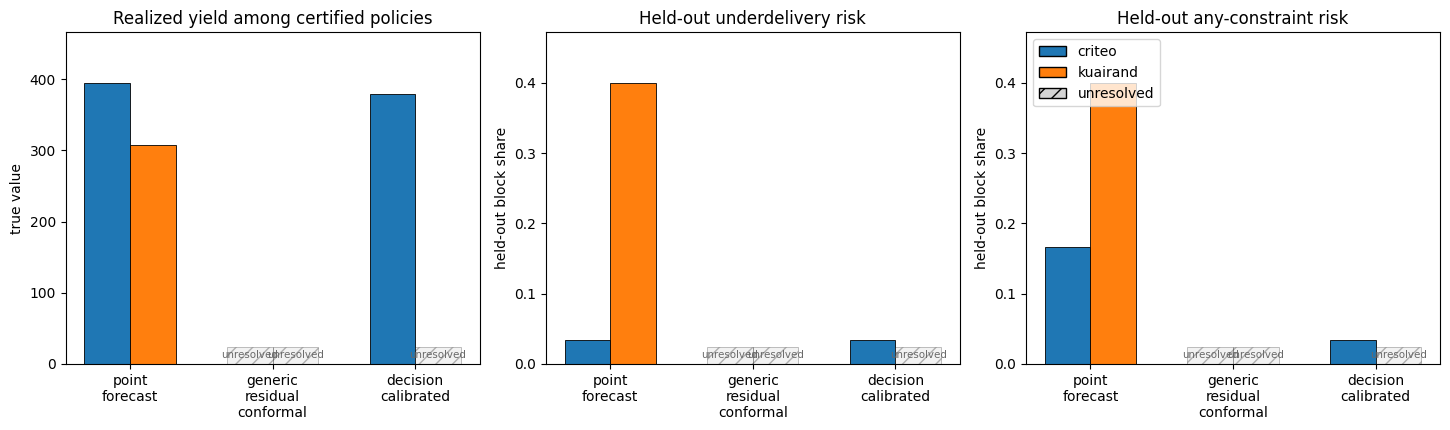

In [1]:
from pathlib import Path
import sys
import pandas as pd

CODE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(CODE_DIR))

from src.experiments import compare_pacing_methods
from src.figures import plot_pacing_comparison
from src.tables import write_table

frames = []
score_frames = []
for case in ['criteo', 'kuairand']:
    result, scores = compare_pacing_methods(case, model='numpy_mlp', max_rows=500_000)
    frames.append(result)
    score_frames.append(scores)

main = pd.concat(frames, ignore_index=True)
score_table = pd.concat(score_frames, ignore_index=True)
write_table(main, '01_main_pacing_results.csv')
write_table(score_table, '01_policy_score_table.csv')
plot_pacing_comparison(main, 'main_pacing_comparison.png')
main